<a href="https://colab.research.google.com/github/diayuunr/CVL_Assignment01/blob/main/CVL_Assignment01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**1. DARK IMAGE --> Log Transform**

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


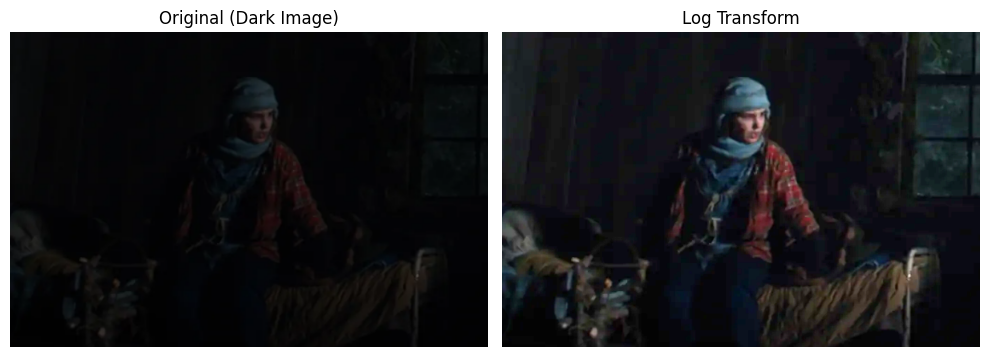

In [49]:
import cv2
import os
import numpy as np
from matplotlib import pyplot as plt
from google.colab import drive
drive.mount('/content/drive')

path_folder = '/content/drive/MyDrive/CVL_Assignment01/'
files = os.listdir(path_folder)

img_path = os.path.join(path_folder,'dark1.png')
img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

#rumus log transform => s = T(r) = c log(1+r)
img_normalize = img / 255.0
c = 1
log_transform = c * np.log(1 + img_normalize)

log_transform = log_transform / np.max(log_transform)
log_transform = np.uint8(log_transform * 255)

fig, axs = plt.subplots(1, 2, figsize=(10, 5))

axs[0].imshow(img)
axs[0].set_title("Original (Dark Image)")
axs[0].axis("off")

axs[1].imshow(log_transform)
axs[1].set_title("Log Transform")
axs[1].axis("off")

plt.tight_layout()
plt.show()

**2. LOW CONTRAST IMAGE --> Contrast Stretching**

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


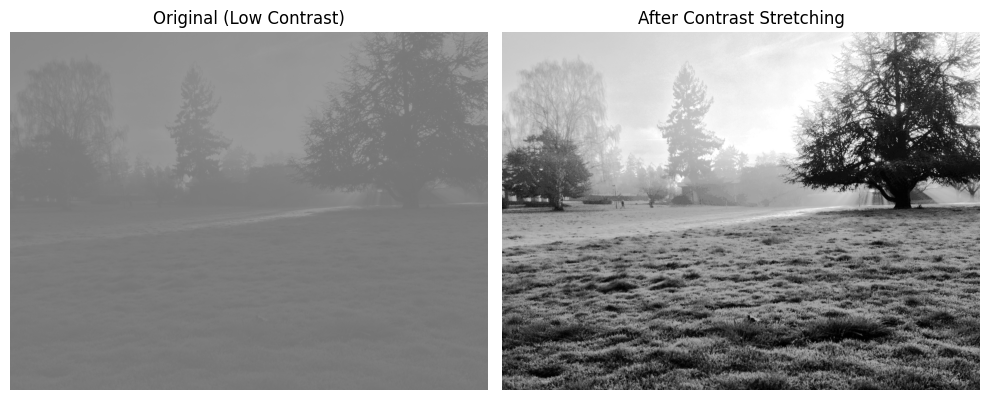

In [41]:
import cv2
import os
import numpy as np
from matplotlib import pyplot as plt
from google.colab import drive
drive.mount('/content/drive')

path_folder = '/content/drive/MyDrive/CVL_Assignment01/'
files = os.listdir(path_folder)

img_path = os.path.join(path_folder,'lowContrast1.png')
img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

if img is None:
    print("Gambar tidak ditemukan. Cek path atau nama file!")
else:
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    #rumus Contrast Stretching
    #P_out = (P_in - min) * ( (b - a) / (max_in - min_in) ) + a

    #[min_in, max_in]
    xp = [np.min(img_rgb), np.max(img_rgb)]
    #[a, b]
    fp = [0, 255]

    # Melakukan interpolasi linear untuk stretching
    img_stretched = np.interp(img_rgb, xp, fp).astype(np.uint8)

fig, axs = plt.subplots(1, 2, figsize=(10, 5))

axs[0].imshow(img)
axs[0].set_title('Original (Low Contrast)')
axs[0].axis('off')

axs[1].imshow(img_output)
axs[1].set_title('After Contrast Stretching')
axs[1].axis('off')

plt.tight_layout()
plt.show()